# Study A granular invariance analysis

In [1]:

from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    SECONDARY_MODELS,
    SECONDARY_STUDIES,
    annotate_secondary_reportability,
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    secondary_lane_summary,
    secondary_missing_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = Path("benchmark/runtime").resolve()
if not (runtime_root / "metric-results").exists():
    runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
flat = load_secondary_flat(metric_root)
coverage = load_secondary_coverage(metric_root)
flat = annotate_secondary_reportability(flat)
metric_root

study = "study_a"
study_df = flat[(flat["study"] == study) & (flat["lane"].isin(["invariance", "ctrl-invariance"]))].copy()
study_coverage = coverage[(coverage["study"] == study) & (coverage["lane"].isin(["invariance", "ctrl-invariance"]))].copy()


## Coverage

In [2]:
display(study_coverage[["lane", "model", "status", "use_nli", "nli_stride", "data_root"]])
display(secondary_missing_table(study_coverage)[["lane", "model", "study", "status"]])

,lane,model,status,use_nli,nli_stride,data_root
30,invariance,deepseek-r1-lmstudio,missing_cache,NaN,NaN,NaN
35,invariance,piaget-8b-local,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
40,invariance,qwen3-lmstudio,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
45,invariance,gpt-oss-20b,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
50,invariance,psyche-r1-local,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
55,invariance,psyllm-lmstudio,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
60,ctrl-invariance,deepseek-r1-lmstudio,missing_cache,NaN,NaN,NaN
65,ctrl-invariance,piaget-8b-local,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
70,ctrl-invariance,qwen3-lmstudio,ok,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
75,ctrl-invariance,gpt-oss-20b,not_measurable,True,1.0,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status
0,ctrl-invariance,deepseek-r1-lmstudio,study_a,missing_cache
1,ctrl-invariance,gpt-oss-20b,study_a,not_measurable
2,ctrl-invariance,psyche-r1-local,study_a,missing_cache
3,invariance,deepseek-r1-lmstudio,study_a,missing_cache


## Paired deltas by lane

In [3]:
display(study_df.sort_values(["lane", "metric", "model"])[["lane", "model", "metric", "n_pairs", "base_value", "variant_value", "delta", "ci_low", "ci_high", "threshold_claim"]].round(4))

,lane,model,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
239,ctrl-invariance,gpt-oss-20b,acc_cot,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
209,ctrl-invariance,piaget-8b-local,acc_cot,139,0.0072,0.0432,0.0360,0.0000,0.0719,CI overlaps zero; descriptive only
255,ctrl-invariance,psyllm-lmstudio,acc_cot,102,0.0000,0.0000,0.0000,0.0000,0.0000,CI overlaps zero; descriptive only
224,ctrl-invariance,qwen3-lmstudio,acc_cot,139,0.0000,0.0144,0.0144,0.0000,0.0360,CI overlaps zero; descriptive only
240,ctrl-invariance,gpt-oss-20b,acc_early,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
210,ctrl-invariance,piaget-8b-local,acc_early,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
256,ctrl-invariance,psyllm-lmstudio,acc_early,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
225,ctrl-invariance,qwen3-lmstudio,acc_early,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
237,ctrl-invariance,gpt-oss-20b,faithfulness_gap,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows
207,ctrl-invariance,piaget-8b-local,faithfulness_gap,0,NaN,NaN,NaN,NaN,NaN,Not measurable from available paired rows


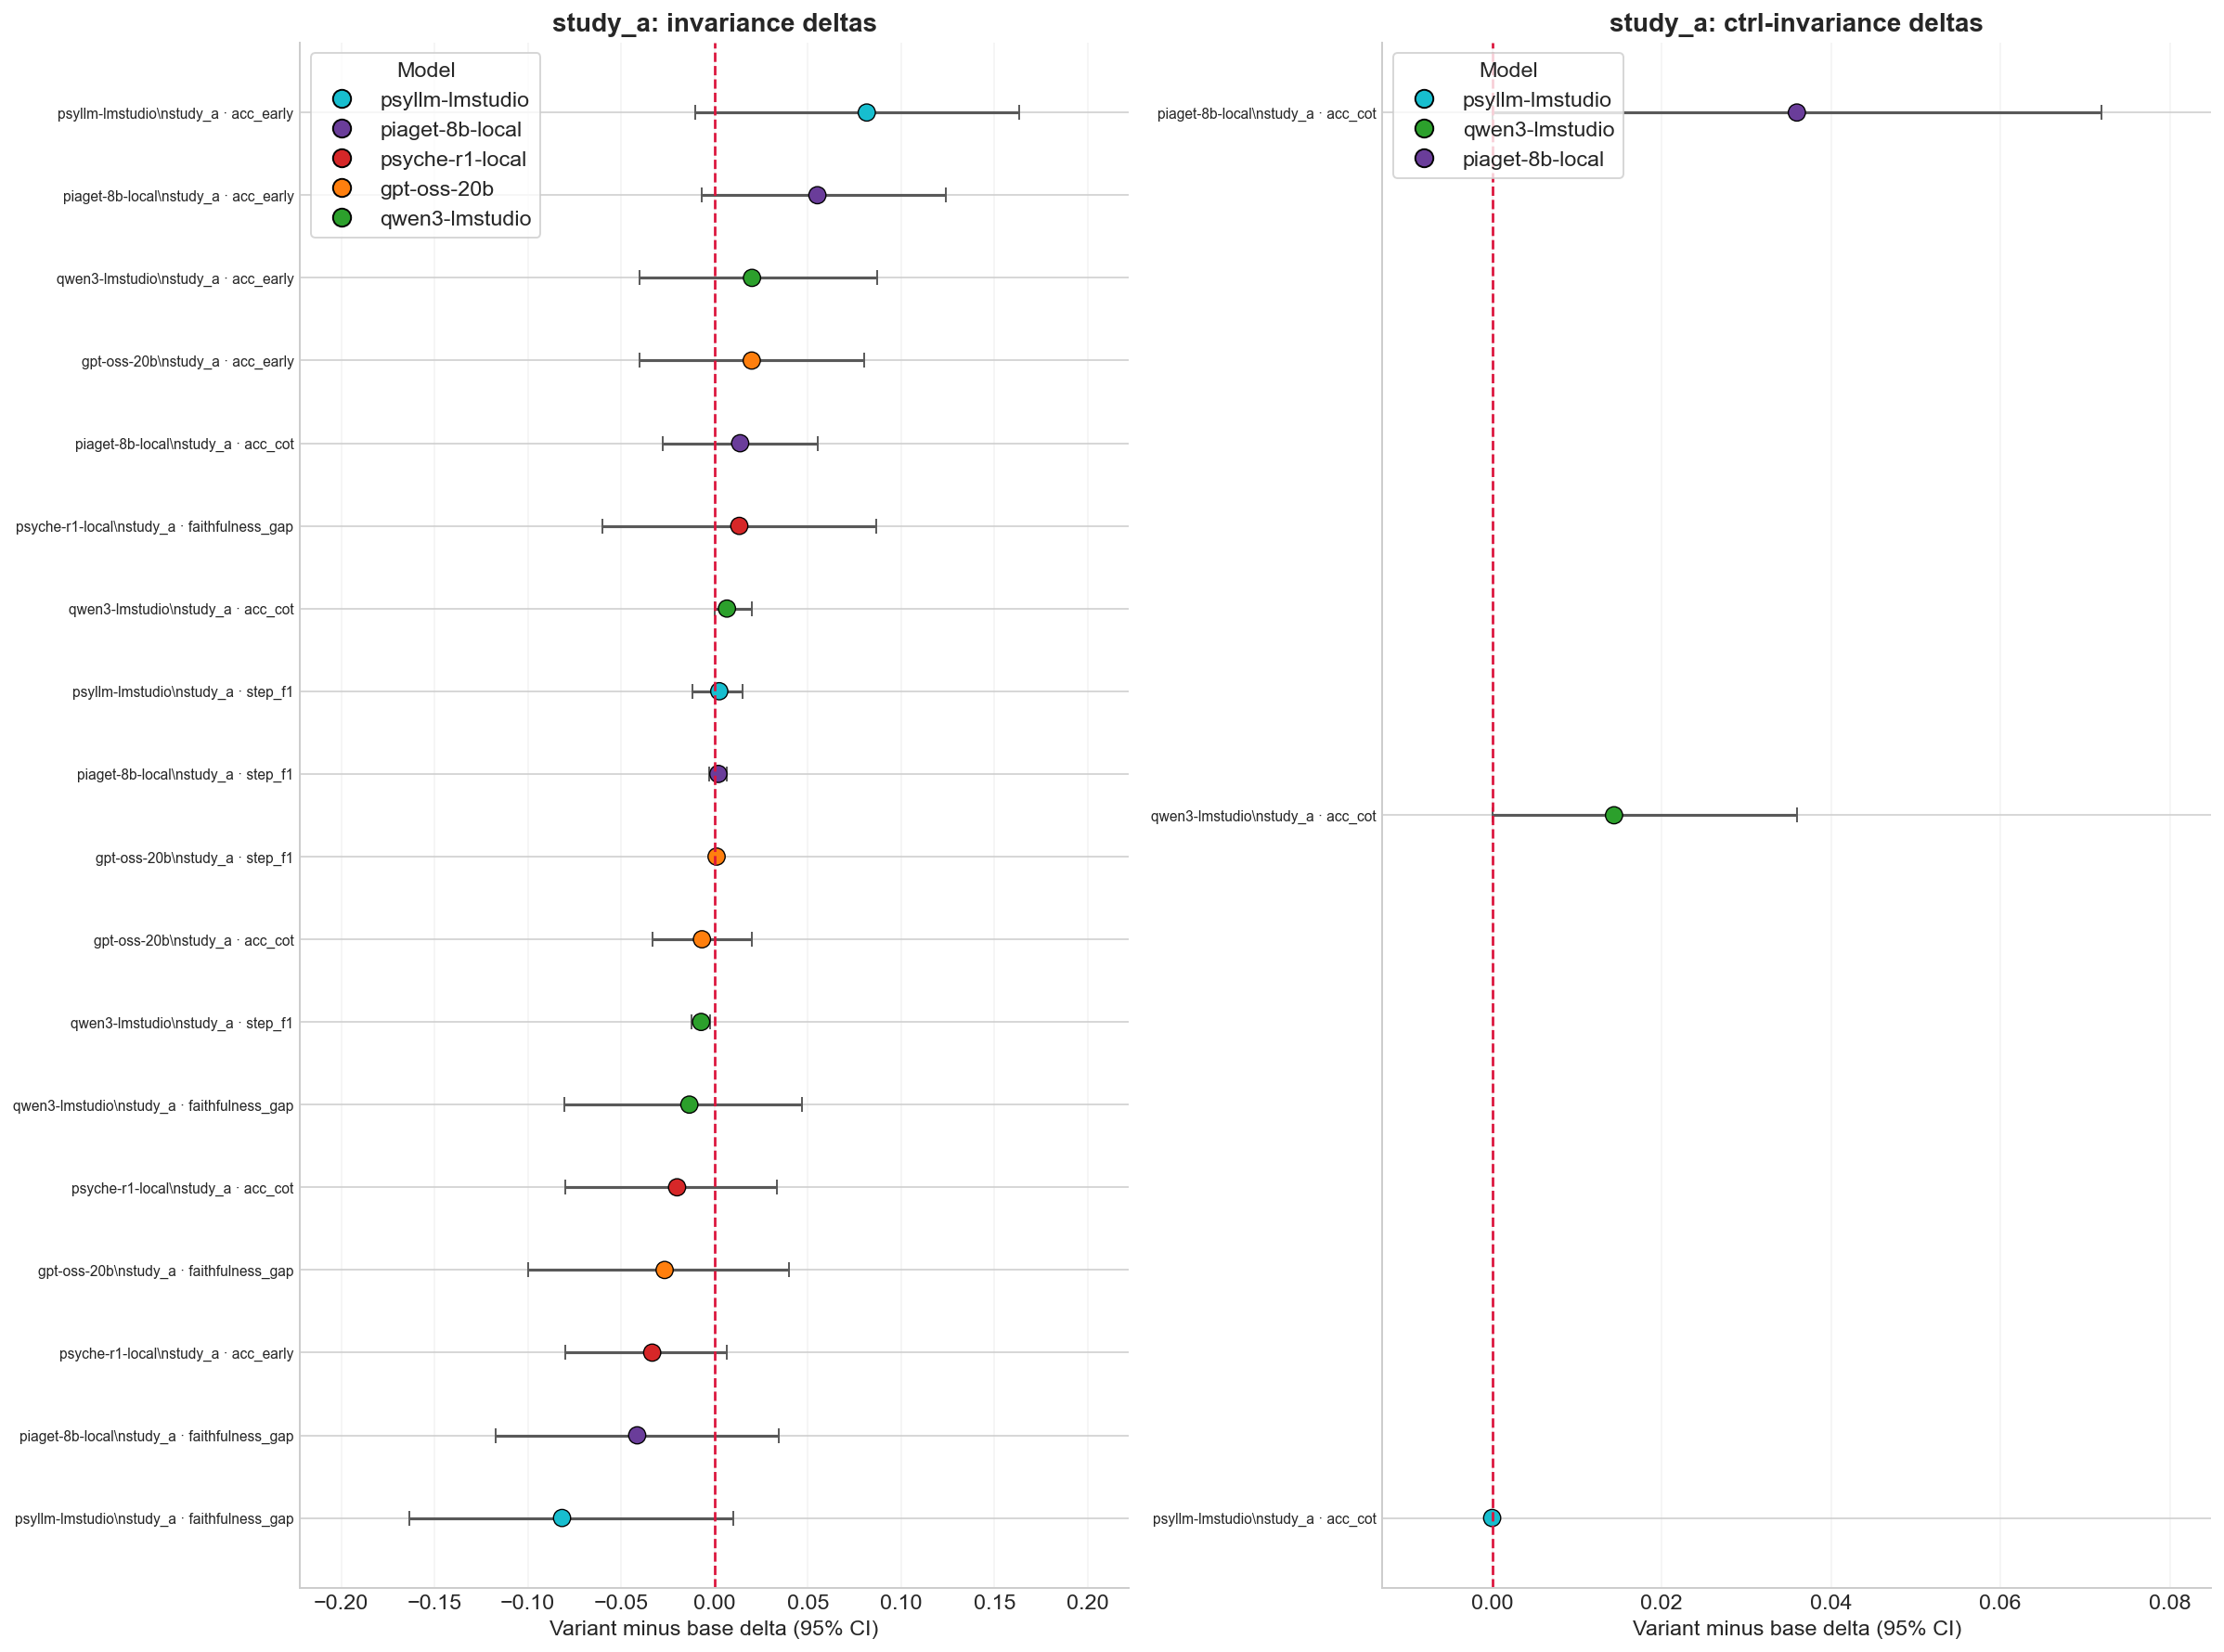

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, max(5, 0.35 * max(len(study_df), 8))), constrained_layout=True)
for ax, lane in zip(axes, ["invariance", "ctrl-invariance"]):
    plot_secondary_delta_ci(study_df[study_df["lane"] == lane], ax=ax, title=f"{study}: {lane} deltas", max_rows=18)
plt.show()

Use this granular view for case-study selection: prioritise rows with CI excluding zero and the largest absolute paired deltas.